In [1]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from DataManagement import DataHandler, DefaultDataHandler, ImprovedDataHandler,DataViewer
from ModelPipelines import DefaultPipeline, XGBoostSurvivalPipeline
from sksurv.util import Surv
from config import PARAMS_RSF, PARAMS_XGB
from sksurv.metrics import concordance_index_ipcw,concordance_index_censored
import logging
import os
import numpy as np
from LearningCurve import learning_curve_analysis, RiskScorePlotter
from GridSearch import ModelSelection

In [2]:
# Load data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
target_df = pd.read_csv("./target_train.csv", index_col=0)

In [3]:
# first let's plot some graphs on initial data
# let's aggregate the info into one Dataframe

joined_initial_data = df.merge(maf_df, left_index=True, right_index=True, how='left')
joined_initial_data = joined_initial_data.drop(columns=['START', 'END'])
# for the molecular data
dtm = DataViewer(joined_initial_data, target_df)

# first let's plot the analysis in terms of missing data....
dtm.stats_analysis().head(25)


,dtype,count_nan,nan_percentage,distinct_values,count,mean,std,min,25%,50%,75%,max
CENTER,object,0,0.000000,23,11232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_BLAST,float64,420,3.739316,139,10812.0,6.851878,8.169294,0.0,2.0,4.0,10.0,91.0
WBC,float64,939,8.360043,699,10293.0,7.808363,12.895303,0.2,2.7,4.2,7.21,154.4
ANC,float64,685,6.098647,1026,10547.0,3.799921,6.793446,0.0,1.0,2.0,4.0,109.62
MONOCYTES,float64,2049,18.242521,609,9183.0,1.343019,3.49102,0.0,0.15,0.4,1.0,44.2
HB,float64,382,3.400997,239,10850.0,9.835244,2.035172,4.0,8.48,9.666,11.1,16.6
PLT,float64,434,3.863960,586,10798.0,158.834572,152.570387,2.0,61.0,114.0,209.0,1451.0
CYTOGENETICS,object,1408,12.535613,1194,9824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHR,object,411,3.659188,23,10821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REF,object,411,3.659188,406,10821,NaN,NaN,NaN,NaN,NaN,NaN,NaN


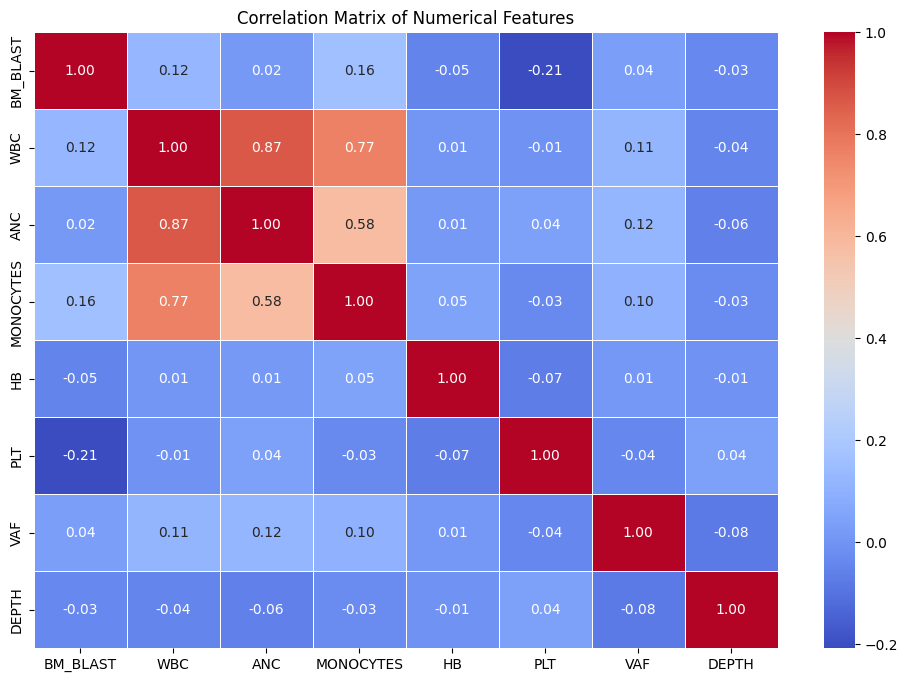

In [4]:
# now, the correlation matrix between the numerical features
dtm.plot_correlation_matrix()

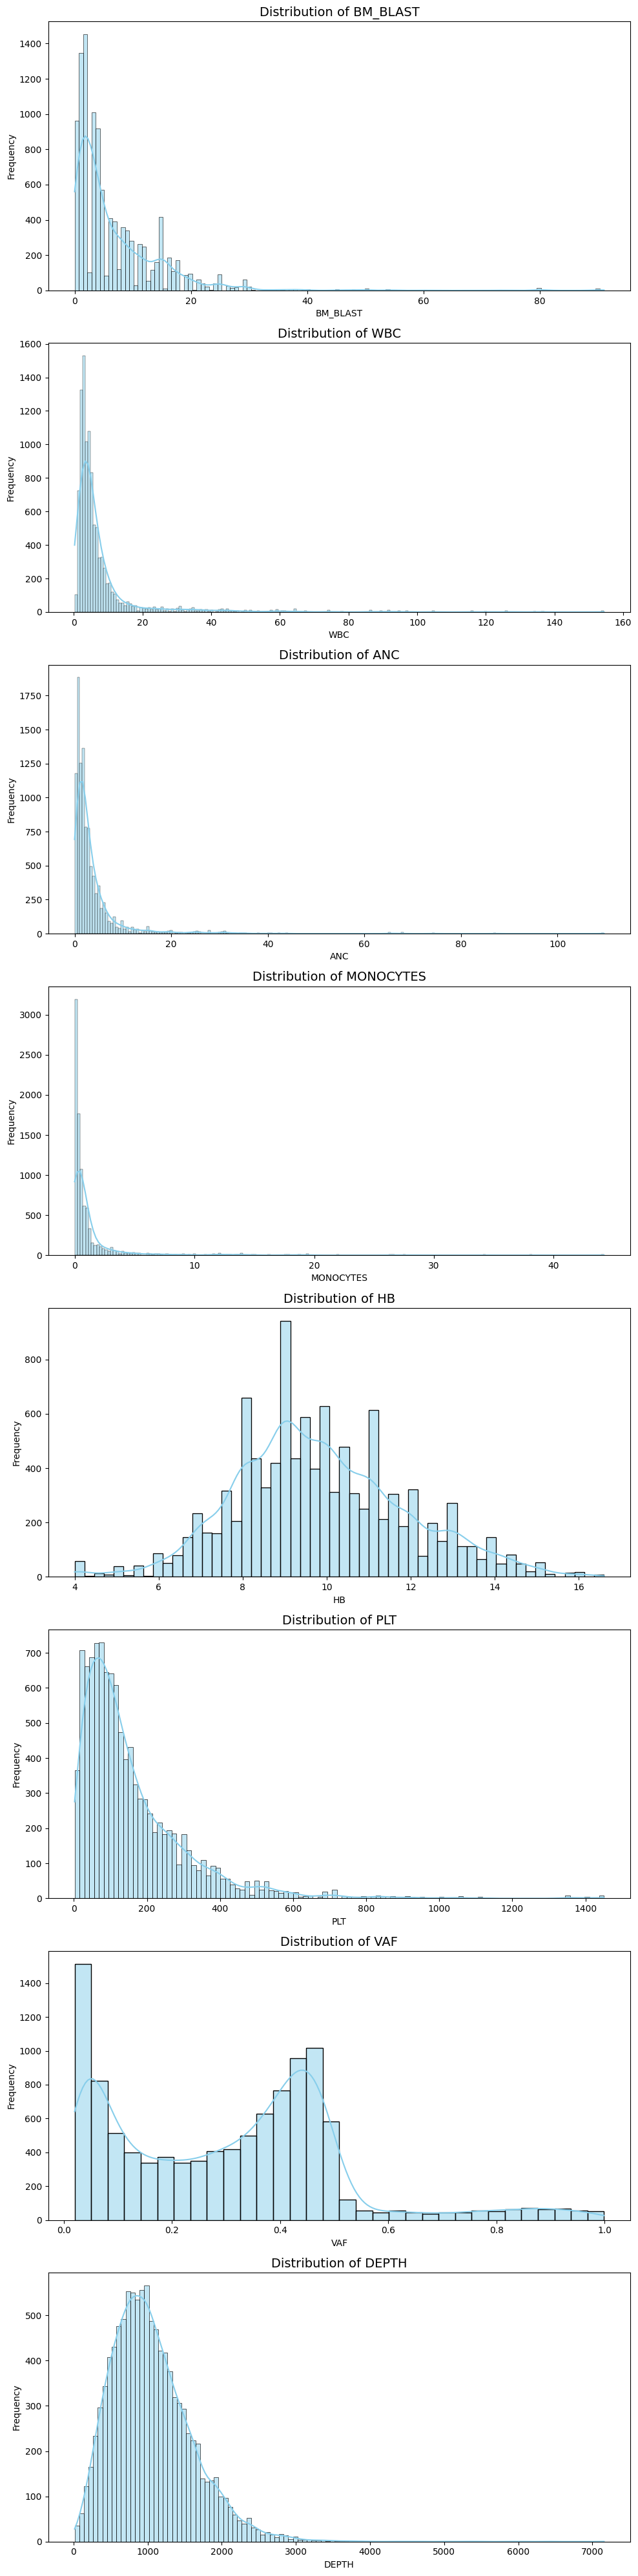

In [5]:
# now the distribution of the numerical variables
dtm.plot_float_distributions()

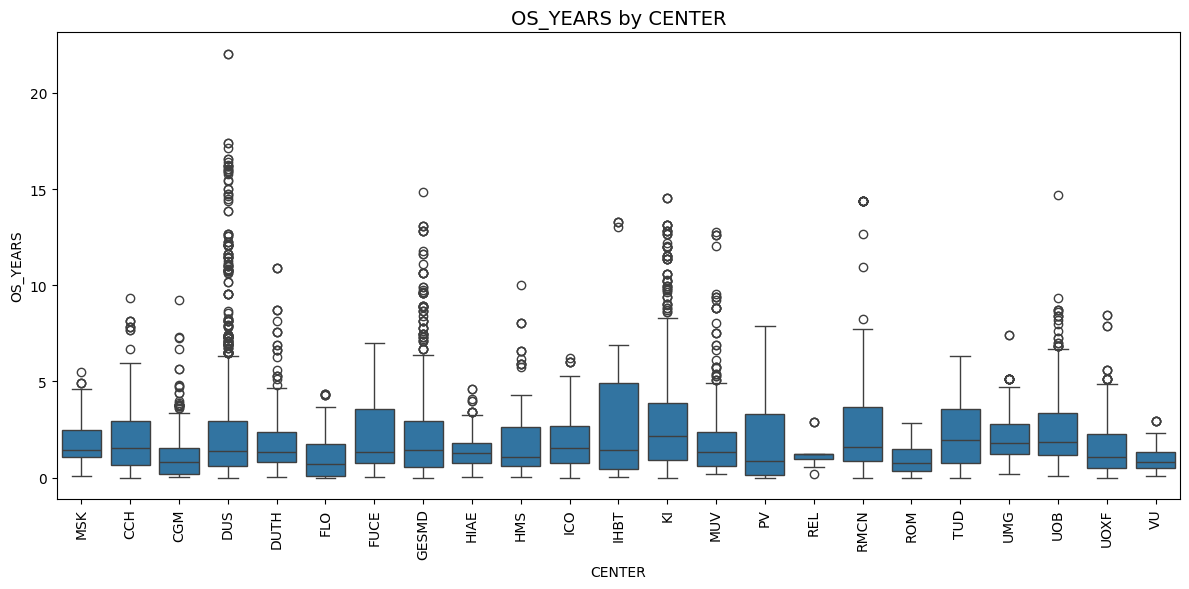

In [6]:
dtm.plot_categorical_boxplot(["CENTER"])

In [7]:
# pipeline

    # Build and fit pipeline
data_handler = ImprovedDataHandler(df, maf_df, target_df)
prepared_data = data_handler.prepare()
pipeline_builder = DefaultPipeline(prepared_data)
pipeline = pipeline_builder.build_pipeline()

train_cols = prepared_data[0].columns.tolist()

    # transform the target data
y_surv = Surv.from_dataframe(
    event='OS_STATUS',   # 1 = event, 0 = censored
    time='OS_YEARS',
    data=prepared_data[1]
)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_missing', ...), ('column_transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,0.2
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [8]:
# gridsearch
# first, we will train our model on a random survival forest

grid_search = ModelSelection(model=pipeline, param_grid=PARAMS_RSF, cv=5)
grid_search.fit(prepared_data[0], y_surv)
print("Best Parameters:", grid_search.best_params())    
print("Best Score:", grid_search.best_score())


2026-03-18 12:44:25,079 - INFO - Initialized ModelSelection with model: Pipeline, cv: 5, n_jobs: -1
2026-03-18 12:44:25,079 - INFO - Starting Grid Search with 4 combinations


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=   9.3s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=   9.9s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=   9.8s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=  10.1s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=  10.5s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  17.8s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  

/Users/a33619/Leukemia-Survival-Rate/.venv-2/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=100; total time=   6.3s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=20, model__n_estimators=200; total time=  15.3s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=   9.9s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  10.1s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  10.4s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=   7.9s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=100; total time=   3.6s
[CV] END model__max_features=sqrt, model__min_sam

2026-03-18 12:46:10,234 - INFO - Start looping ...
2026-03-18 12:46:10,237 - INFO - Iteration : 0.1
2026-03-18 12:46:15,947 - INFO - Iteration : 0.26
2026-03-18 12:46:27,951 - INFO - Iteration : 0.42000000000000004
2026-03-18 12:46:51,291 - INFO - Iteration : 0.58
2026-03-18 12:47:35,984 - INFO - Iteration : 0.74
2026-03-18 12:48:40,008 - INFO - Iteration : 0.9
/Users/a33619/Leukemia-Survival-Rate/LearningCurve.py:107: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.lineplot(


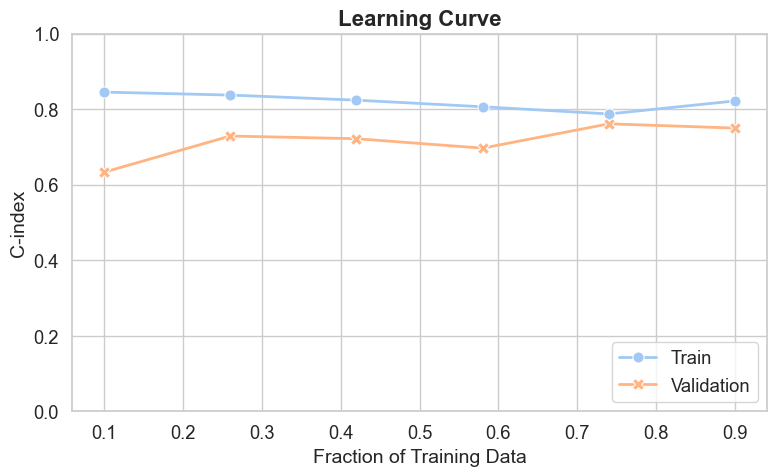

In [9]:
# now, let's plot the learning curve to make sure we don't overfit

learning_curve_analysis(pipeline, prepared_data[0], y_surv, PARAMS_RSF)

In [10]:
# we don't seem to overfit, no problems of overfitting

Loading Scores...
Done.


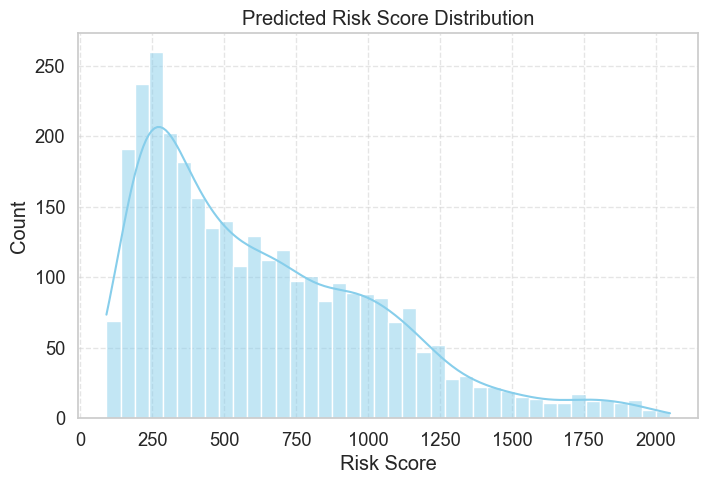

In [11]:
# plot a few graphs on the risk score / predicted survival...

# first the predicted risk score distribution
best_model=grid_search.best_model
print("Loading Scores...")    
plotter = RiskScorePlotter(model=best_model, X=prepared_data[0], y=y_surv)
print("Done.")
plotter.plot_overall_distribution()

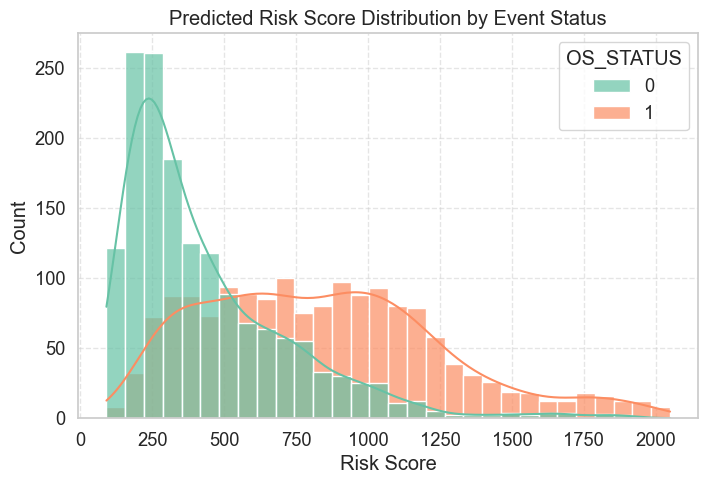

In [12]:
# first distribution of survival prediction per event (0 or 1)
plotter.plot_by_event_status()

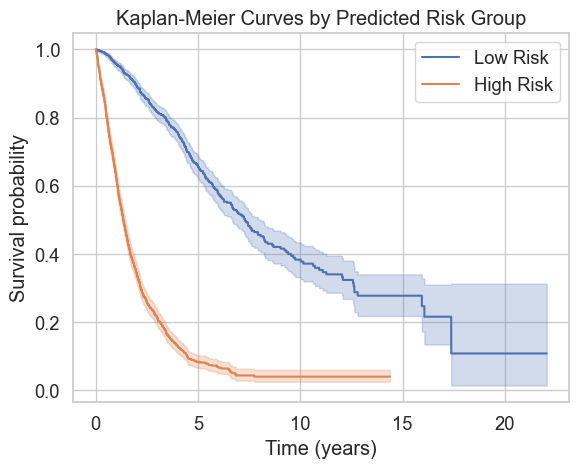

In [13]:
# plot kaplan meyer curve
plotter.plot_kaplan_meier()

In [14]:

# now, we will test trainig our model on a xgboost

# pipeline

    # Build and fit pipeline
data_handler = ImprovedDataHandler(df, maf_df, target_df)
prepared_data = data_handler.prepare()
pipeline_builder = XGBoostSurvivalPipeline(prepared_data)
pipeline = pipeline_builder.build_pipeline()

train_cols = prepared_data[0].columns.tolist()

    # transform the target data
y_surv = Surv.from_dataframe(
    event='OS_STATUS',   # 1 = event, 0 = censored
    time='OS_YEARS',
    data=prepared_data[1]
)

# gridsearch
grid_search = ModelSelection(model=pipeline, param_grid=PARAMS_XGB, cv=5)
grid_search.fit(prepared_data[0], y_surv)
print("Best Parameters:", grid_search.best_params())    
print("Best Score:", grid_search.best_score())


2026-03-18 12:50:32,846 - INFO - Initialized ModelSelection with model: Pipeline, cv: 5, n_jobs: -1
2026-03-18 12:50:32,847 - INFO - Starting Grid Search with 6 combinations


Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=0.8; total time=   1.4s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=0.8; total time=   1.4s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=0.8; total time=   1.4s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=1.0; total time=   1.4s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=1.0; total time=   1.4s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, mod

2026-03-18 12:50:59,110 - INFO - Start looping ...
2026-03-18 12:50:59,112 - INFO - Iteration : 0.1
2026-03-18 12:51:14,850 - INFO - Iteration : 0.26
2026-03-18 12:51:36,520 - INFO - Iteration : 0.42000000000000004
2026-03-18 12:52:04,346 - INFO - Iteration : 0.58
2026-03-18 12:52:33,697 - INFO - Iteration : 0.74
2026-03-18 12:53:08,324 - INFO - Iteration : 0.9
/Users/a33619/Leukemia-Survival-Rate/LearningCurve.py:107: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.lineplot(


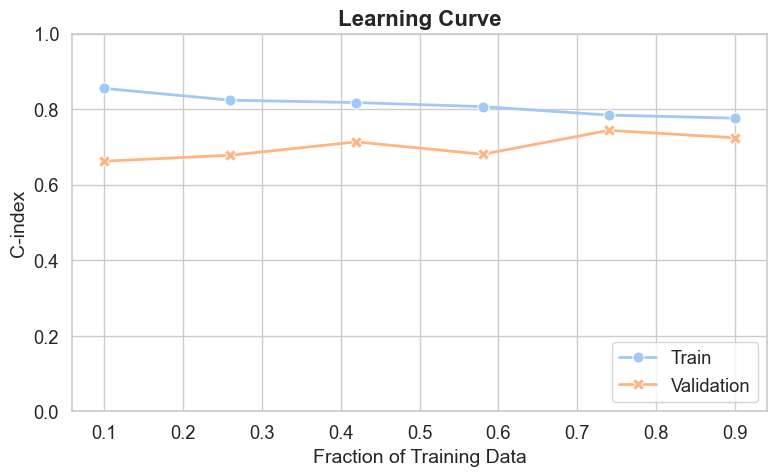

In [15]:
# score looks lower, let's plot curve anyway

# now, let's plot the learning curve to make sure we don't overfit

learning_curve_analysis(pipeline, prepared_data[0], y_surv, PARAMS_XGB)

In [16]:
# learning curve doesn't overfit but isn't as good as before

Loading Scores...
Done.


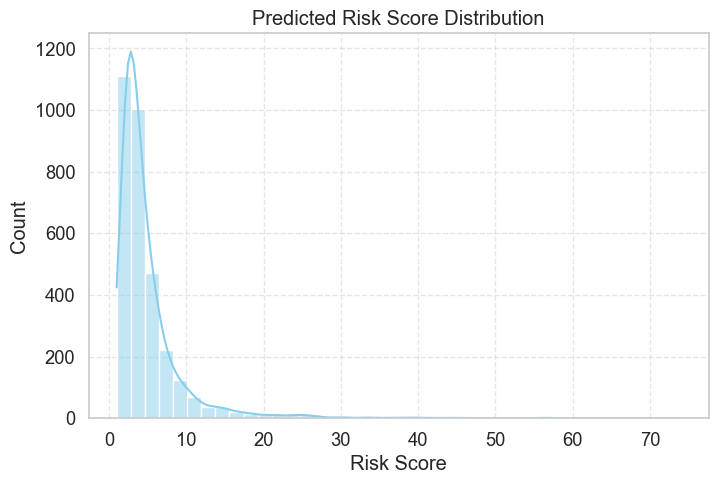

In [17]:
# plot risk scores for patients (first, risk score distribution
best_model=grid_search.best_model
print("Loading Scores...")
plotter = RiskScorePlotter(model=best_model, X=prepared_data[0], y=y_surv)
print("Done.")
plotter.plot_overall_distribution()

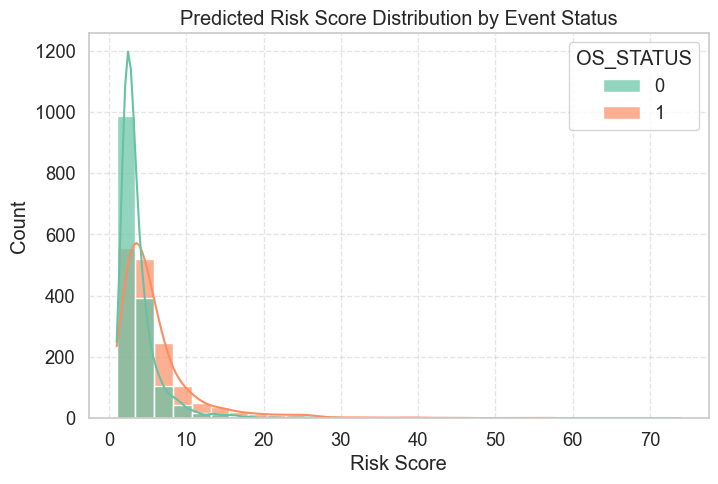

In [18]:
# first distribution of survival prediction per event (0 or 1)
plotter.plot_by_event_status()

In [19]:
# distribution isn't as differenciated by status, proves again it's not as good as the RSF

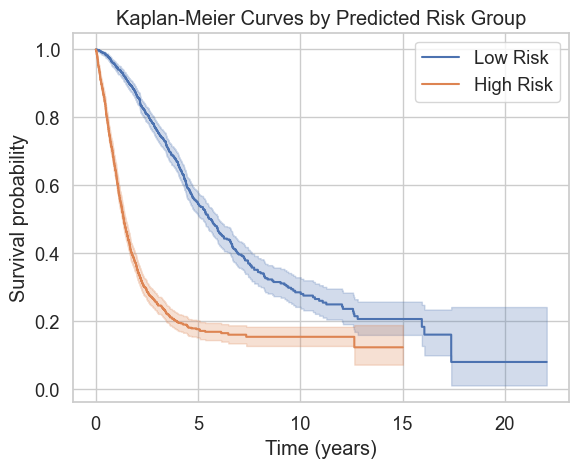

In [20]:
# plot kaplan meyer curve
plotter.plot_kaplan_meier()